**Capítulo 10 – Introdução às Redes Neurais Artificiais com Keras**

_Este notebook contém todo o código de exemplo e soluções para os exercícios do capítulo 10._ markdown jupyter organizado

<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/ageron/handson-ml2/blob/master/10_neural_nets_with_keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/ageron/handson-ml2/blob/master/10_neural_nets_with_keras.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" /></a>
  </td>
</table>

# Setup

Primeiro, vamos importar alguns módulos comuns, garantir que o MatplotLib exiba as figuras inline e preparar uma função para salvar as figuras. Também verificamos se o Python 3.5 ou posterior está instalado (embora o Python 2.x possa funcionar, ele está obsoleto, então recomendamos fortemente que você use o Python 3), assim como o Scikit-Learn ≥0.20 e o TensorFlow ≥2.0.

In [11]:
# Python ≥3.5 é necessário
import sys
assert sys.version_info >= (3, 5)

# Scikit-Learn ≥0.20 é necessário
import sklearn
assert sklearn.__version__ >= "0.20"

try:
    # %tensorflow_version existe apenas no Colab.
    %tensorflow_version 2.x
except Exception:
    pass

# TensorFlow ≥2.0 é necessário
import tensorflow as tf
assert tf.__version__ >= "2.0"

# Importações comuns
import numpy as np
import os

# para tornar a saída deste notebook estável entre execuções
np.random.seed(42)

# Para plotar figuras bonitas
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# Onde salvar as figuras
PROJECT_ROOT_DIR = "."
CHAPTER_ID = "ann"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", CHAPTER_ID)
os.makedirs(IMAGES_PATH, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    """
    Salva a figura atual do matplotlib em um arquivo.
    
    Parâmetros:
        fig_id: identificador/nome da figura (sem extensão)
        tight_layout: se True, ajusta automaticamente o layout da figura
        fig_extension: formato do arquivo (png, jpg, pdf, etc.)
        resolution: DPI (dots per inch) da imagem salva
    """
    # Constrói o caminho completo do arquivo
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    
    # Exibe mensagem informando onde a figura está sendo salva
    print(f"Salvando figura '{fig_id}' em: {os.path.abspath(path)}")
    
    # Ajusta o layout da figura para evitar cortes
    if tight_layout:
        plt.tight_layout()
    
    # Salva a figura no formato e resolução especificados
    plt.savefig(path, format=fig_extension, dpi=resolution)
    
    # Confirma que a figura foi salva
    print(f"✓ Figura salva com sucesso!")

# Perceptrons

**Nota**: definimos `max_iter` e `tol` explicitamente para evitar avisos sobre o fato de que seus valores padrão serão alterados em futuras versões do Scikit-Learn.

In [14]:
# Importa a biblioteca NumPy para operações numéricas
import numpy as np
# Importa o dataset Iris do Scikit-Learn
from sklearn.datasets import load_iris
# Importa o algoritmo Perceptron do Scikit-Learn
from sklearn.linear_model import Perceptron

# Carrega o dataset Iris
iris = load_iris()

# Seleciona apenas as colunas 2 e 3 (comprimento e largura da pétala)
X = iris.data[:, (2, 3)]  # petal length, petal width

# Cria variável target: 1 se a flor for setosa (classe 0), 0 caso contrário
# Nota: np.int foi removido no NumPy 2.0, usar int nativo do Python
y = (iris.target == 0).astype(int)

# Inicializa o classificador Perceptron com parâmetros específicos
# max_iter: número máximo de iterações sobre os dados de treino
# tol: tolerância para o critério de parada
# random_state: seed para reprodutibilidade dos resultados
per_clf = Perceptron(max_iter=1000, tol=1e-3, random_state=42)

# Treina o modelo com os dados de entrada X e os rótulos y
per_clf.fit(X, y)

# Faz uma predição para uma nova amostra (comprimento=2, largura=0.5)
y_pred = per_clf.predict([[2, 0.5]])

In [15]:
y_pred

array([1])

Salvando figura 'perceptron_iris_plot' em: c:\welligton-pos-IA\aprendizado_maquina\Apredizado-de-maquinae-livro\images\ann\perceptron_iris_plot.png
✓ Figura salva com sucesso!


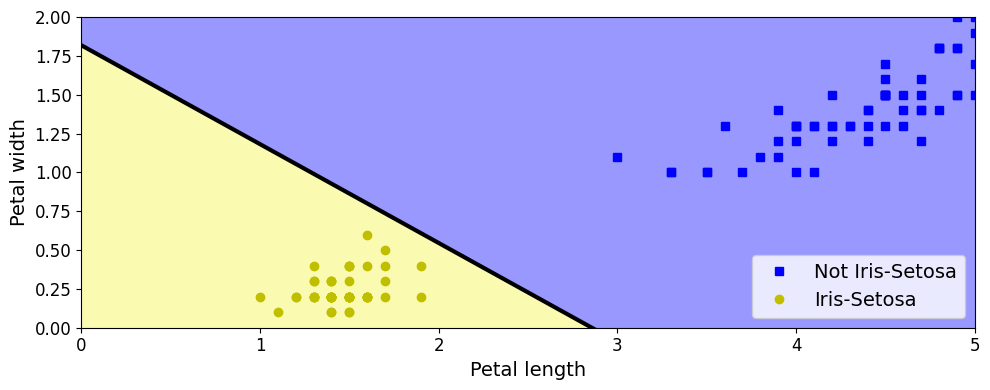

In [17]:
# Calcula o coeficiente angular da linha de decisão
# a = -w1/w2, onde w1 e w2 são os pesos do perceptron
a = -per_clf.coef_[0][0] / per_clf.coef_[0][1]

# Calcula o coeficiente linear da linha de decisão
# b = -intercept/w2
b = -per_clf.intercept_ / per_clf.coef_[0][1]

# Define os limites dos eixos do gráfico [x_min, x_max, y_min, y_max]
axes = [0, 5, 0, 2]

# Cria uma grade de pontos para visualizar as regiões de decisão
# meshgrid gera coordenadas x0 e x1 para cobrir toda a área do gráfico
x0, x1 = np.meshgrid(
        np.linspace(axes[0], axes[1], 500).reshape(-1, 1),  # 500 pontos no eixo x
        np.linspace(axes[2], axes[3], 200).reshape(-1, 1),  # 200 pontos no eixo y
    )

# Combina as coordenadas x0 e x1 em uma matriz de features
X_new = np.c_[x0.ravel(), x1.ravel()]

# Faz predições para todos os pontos da grade
y_predict = per_clf.predict(X_new)

# Reorganiza as predições no formato da grade original
zz = y_predict.reshape(x0.shape)

# Cria uma figura com tamanho 10x4 polegadas
plt.figure(figsize=(10, 4))

# Plota as amostras que NÃO são Iris-Setosa (classe 0) como quadrados azuis
plt.plot(X[y==0, 0], X[y==0, 1], "bs", label="Not Iris-Setosa")

# Plota as amostras que SÃO Iris-Setosa (classe 1) como círculos amarelos
plt.plot(X[y==1, 0], X[y==1, 1], "yo", label="Iris-Setosa")

# Desenha a linha de decisão do perceptron em preto com espessura 3
plt.plot([axes[0], axes[1]], [a * axes[0] + b, a * axes[1] + b], "k-", linewidth=3)

# Importa ListedColormap para criar um mapa de cores personalizado
from matplotlib.colors import ListedColormap

# Define cores personalizadas para as regiões de decisão
custom_cmap = ListedColormap(['#9898ff', '#fafab0'])

# Preenche as regiões de decisão com as cores personalizadas
plt.contourf(x0, x1, zz, cmap=custom_cmap)

# Define o rótulo do eixo x
plt.xlabel("Petal length", fontsize=14)

# Define o rótulo do eixo y
plt.ylabel("Petal width", fontsize=14)

# Adiciona a legenda no canto inferior direito
plt.legend(loc="lower right", fontsize=14)

# Define os limites dos eixos
plt.axis(axes)

# Salva a figura usando a função definida anteriormente
save_fig("perceptron_iris_plot")

# Exibe o gráfico
plt.show()

# Activation functions

In [19]:
def sigmoid(z):
    """
    Função de ativação Sigmoid (logística).
    Transforma qualquer valor em um número entre 0 e 1.
    Fórmula: σ(z) = 1 / (1 + e^(-z))
    """
    return 1 / (1 + np.exp(-z))

def relu(z):
    """
    Função de ativação ReLU (Rectified Linear Unit).
    Retorna o valor se positivo, caso contrário retorna 0.
    Fórmula: ReLU(z) = max(0, z)
    """
    return np.maximum(0, z)

def derivative(f, z, eps=0.000001):
    """
    Calcula a derivada numérica de uma função em um ponto específico.
    Usa o método das diferenças finitas centrais.
    
    Parâmetros:
        f: função a ser derivada
        z: ponto onde calcular a derivada
        eps: pequeno incremento usado no cálculo (epsilon)
    
    Retorna:
        Aproximação da derivada f'(z)
    
    Fórmula: f'(z) ≈ [f(z + ε) - f(z - ε)] / (2ε)
    """
    return (f(z + eps) - f(z - eps))/(2 * eps)

# Visualização de Funções de Ativação e suas Derivadas

## Objetivo
Este código cria uma visualização comparativa de diferentes funções de ativação utilizadas em redes neurais artificiais, mostrando tanto as funções originais quanto suas derivadas.

## Funções de Ativação Plotadas

### 1. **Step (Degrau)**
- **Definição**: Retorna -1 para valores negativos e 1 para valores positivos
- **Uso**: Perceptron clássico
- **Problema**: Derivada zero em quase todos os pontos (não permite backpropagation)

### 2. **Sigmoid (Logística)**
- **Definição**: σ(z) = 1 / (1 + e^(-z))
- **Intervalo**: Saída entre 0 e 1
- **Uso**: Camadas de saída para classificação binária
- **Características**: Suave, diferenciável, mas sofre do problema de gradientes desvanecentes

### 3. **Tanh (Tangente Hiperbólica)**
- **Definição**: tanh(z) = (e^z - e^(-z)) / (e^z + e^(-z))
- **Intervalo**: Saída entre -1 e 1
- **Vantagem**: Centrada em zero, melhor que sigmoid para camadas ocultas
- **Problema**: Também sofre de gradientes desvanecentes

### 4. **ReLU (Rectified Linear Unit)**
- **Definição**: ReLU(z) = max(0, z)
- **Uso**: Função mais popular em redes neurais modernas
- **Vantagens**: 
  - Simples e eficiente computacionalmente
  - Não sofre de gradientes desvanecentes para valores positivos
  - Convergência mais rápida
- **Problema**: "Dying ReLU" (neurônios podem morrer com valores negativos)

## Estrutura do Gráfico

### Subplot 1 (Esquerda): Funções de Ativação
Mostra o comportamento de cada função ao longo do intervalo [-5, 5]:
- **Step**: Transição abrupta em z=0
- **Sigmoid**: Curva suave em forma de S
- **Tanh**: Similar à sigmoid, mas centrada em zero
- **ReLU**: Linear para valores positivos, zero para negativos

### Subplot 2 (Direita): Derivadas
Mostra as taxas de mudança (gradientes) de cada função:
- **Step**: Derivada zero (indefinida em z=0), marcada com ○ e ✕
- **Sigmoid**: Derivada em forma de sino, máxima em z=0
- **Tanh**: Derivada similar à sigmoid, mas com pico mais alto
- **ReLU**: Derivada constante (1) para z>0, zero para z<0

## Importância das Derivadas

As derivadas são cruciais no treinamento de redes neurais porque:
1. **Backpropagation**: Algoritmo usa as derivadas para calcular gradientes
2. **Atualização de pesos**: Gradientes indicam como ajustar os pesos
3. **Velocidade de aprendizado**: Derivadas maiores = aprendizado mais rápido
4. **Gradientes desvanecentes**: Derivadas muito pequenas (sigmoid/tanh em valores extremos) dificultam o aprendizado

## Escolha da Função de Ativação

- **Camadas ocultas**: ReLU (padrão moderno) ou suas variantes (Leaky ReLU, ELU)
- **Saída - classificação binária**: Sigmoid
- **Saída - classificação multiclasse**: Softmax
- **Saída - regressão**: Linear (sem ativação)

Salvando figura 'activation_functions_plot' em: c:\welligton-pos-IA\aprendizado_maquina\Apredizado-de-maquinae-livro\images\ann\activation_functions_plot.png
✓ Figura salva com sucesso!


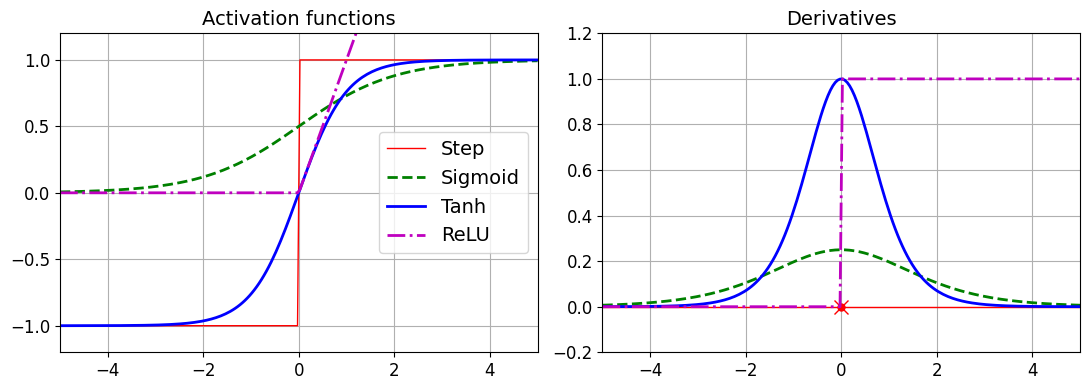

In [21]:
# Cria um array de 200 valores igualmente espaçados entre -5 e 5
z = np.linspace(-5, 5, 200)

# Cria uma figura com tamanho 11x4 polegadas
plt.figure(figsize=(11,4))

# Primeiro subplot: Funções de Ativação
plt.subplot(121)  # 1 linha, 2 colunas, posição 1

# Plota a função Step (degrau) em vermelho com linha sólida
plt.plot(z, np.sign(z), "r-", linewidth=1, label="Step")

# Plota a função Sigmoid em verde com linha tracejada
plt.plot(z, sigmoid(z), "g--", linewidth=2, label="Sigmoid")

# Plota a função Tangente Hiperbólica em azul com linha sólida
plt.plot(z, np.tanh(z), "b-", linewidth=2, label="Tanh")

# Plota a função ReLU em magenta com linha traço-ponto
plt.plot(z, relu(z), "m-.", linewidth=2, label="ReLU")

# Adiciona grade ao gráfico
plt.grid(True)

# Adiciona legenda no centro direito
plt.legend(loc="center right", fontsize=14)

# Define título do gráfico
plt.title("Activation functions", fontsize=14)

# Define limites dos eixos [x_min, x_max, y_min, y_max]
plt.axis([-5, 5, -1.2, 1.2])

# Segundo subplot: Derivadas das Funções de Ativação
plt.subplot(122)  # 1 linha, 2 colunas, posição 2

# Plota a derivada da função Step
plt.plot(z, derivative(np.sign, z), "r-", linewidth=1, label="Step")

# Marca o ponto de descontinuidade em z=0 com círculo vermelho
plt.plot(0, 0, "ro", markersize=5)

# Marca o ponto de descontinuidade em z=0 com X vermelho
plt.plot(0, 0, "rx", markersize=10)

# Plota a derivada da função Sigmoid
plt.plot(z, derivative(sigmoid, z), "g--", linewidth=2, label="Sigmoid")

# Plota a derivada da função Tanh
plt.plot(z, derivative(np.tanh, z), "b-", linewidth=2, label="Tanh")

# Plota a derivada da função ReLU
plt.plot(z, derivative(relu, z), "m-.", linewidth=2, label="ReLU")

# Adiciona grade ao gráfico
plt.grid(True)

# Linha comentada: legenda desabilitada neste subplot
#plt.legend(loc="center right", fontsize=14)

# Define título do gráfico
plt.title("Derivatives", fontsize=14)

# Define limites dos eixos
plt.axis([-5, 5, -0.2, 1.2])

# Salva a figura com o nome especificado
save_fig("activation_functions_plot")

# Exibe os gráficos
plt.show()

In [23]:
def heaviside(z):
    """
    Função de Heaviside (função degrau unitário).
    Retorna 1 se z >= 0, caso contrário retorna 0.
    
    Parâmetros:
        z: valor ou array de entrada
    
    Retorna:
        0 para valores negativos, 1 para valores não-negativos
    """
    return (z >= 0).astype(z.dtype)

def mlp_xor(x1, x2, activation=heaviside):
    """
    Implementa uma rede neural MLP (Multi-Layer Perceptron) para resolver o problema XOR.
    
    O XOR não é linearmente separável, então precisa de uma camada oculta.
    Esta função simula uma rede com:
    - 2 entradas (x1, x2)
    - 2 neurônios na camada oculta
    - 1 neurônio na camada de saída
    
    Arquitetura:
    - Neurônio oculto 1: ativa quando x1 + x2 >= 1.5 (ambos são 1)
    - Neurônio oculto 2: ativa quando x1 + x2 >= 0.5 (pelo menos um é 1)
    - Saída: ativa quando exatamente um dos neurônios ocultos está ativo
    
    Tabela verdade XOR:
    x1 | x2 | saída
    ---|----|----- 
    0  | 0  | 0
    0  | 1  | 1
    1  | 0  | 1
    1  | 1  | 0
    
    Parâmetros:
        x1: primeira entrada (0 ou 1)
        x2: segunda entrada (0 ou 1)
        activation: função de ativação (padrão: heaviside)
    
    Retorna:
        Resultado da operação XOR entre x1 e x2
    """
    return activation(-activation(x1 + x2 - 1.5) + activation(x1 + x2 - 0.5) - 0.5)

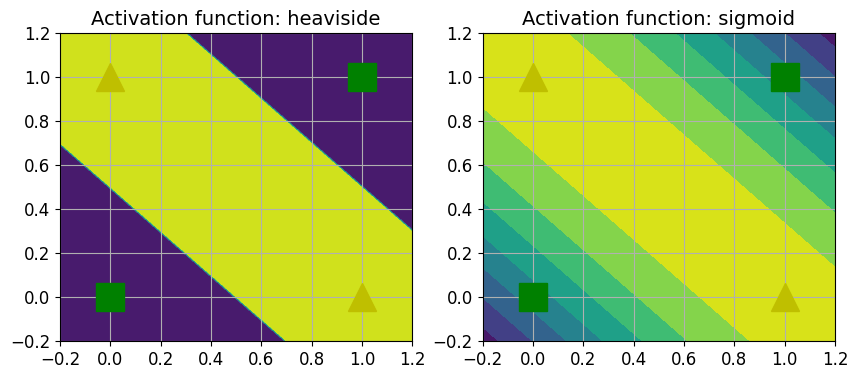

In [24]:
# Cria arrays de 100 valores entre -0.2 e 1.2 para cada eixo
x1s = np.linspace(-0.2, 1.2, 100)
x2s = np.linspace(-0.2, 1.2, 100)

# Cria uma grade 2D com todas as combinações possíveis de x1 e x2
# Isso permite visualizar o comportamento da rede em todo o espaço de entrada
x1, x2 = np.meshgrid(x1s, x2s)

# Calcula a saída do MLP XOR usando a função Heaviside (degrau)
# Produz uma saída binária (0 ou 1)
z1 = mlp_xor(x1, x2, activation=heaviside)

# Calcula a saída do MLP XOR usando a função Sigmoid
# Produz uma saída contínua entre 0 e 1
z2 = mlp_xor(x1, x2, activation=sigmoid)

# Cria uma figura com dois subplots lado a lado
plt.figure(figsize=(10,4))

# Primeiro subplot: MLP com função Heaviside
plt.subplot(121)  # 1 linha, 2 colunas, posição 1

# Cria um mapa de contorno preenchido mostrando as regiões de decisão
plt.contourf(x1, x2, z1)

# Plota os pontos onde XOR deve retornar 0 (False)
# (0,0) e (1,1) → marcados com quadrados verdes
plt.plot([0, 1], [0, 1], "gs", markersize=20)

# Plota os pontos onde XOR deve retornar 1 (True)
# (0,1) e (1,0) → marcados com triângulos amarelos
plt.plot([0, 1], [1, 0], "y^", markersize=20)

# Define o título do primeiro gráfico
plt.title("Activation function: heaviside", fontsize=14)

# Adiciona grade para facilitar a leitura
plt.grid(True)

# Segundo subplot: MLP com função Sigmoid
plt.subplot(122)  # 1 linha, 2 colunas, posição 2

# Cria um mapa de contorno preenchido mostrando transições suaves
plt.contourf(x1, x2, z2)

# Plota os pontos onde XOR deve retornar 0 (False)
plt.plot([0, 1], [0, 1], "gs", markersize=20)

# Plota os pontos onde XOR deve retornar 1 (True)
plt.plot([0, 1], [1, 0], "y^", markersize=20)

# Define o título do segundo gráfico
plt.title("Activation function: sigmoid", fontsize=14)

# Adiciona grade para facilitar a leitura
plt.grid(True)

## Explicação da Visualização

### Objetivo
Comparar o comportamento de uma rede neural MLP resolvendo o problema XOR usando duas funções de ativação diferentes:

1. **Heaviside (esquerda)**: Fronteiras de decisão nítidas e abruptas
2. **Sigmoid (direita)**: Transições suaves e graduais entre regiões

### Marcadores no Gráfico
- **Quadrados verdes (■)**: Entradas onde XOR = 0
  - (0, 0): ambos falsos → falso
  - (1, 1): ambos verdadeiros → falso
  
- **Triângulos amarelos (▲)**: Entradas onde XOR = 1
  - (0, 1): valores diferentes → verdadeiro
  - (1, 0): valores diferentes → verdadeiro

### Diferenças entre as Funções

**Heaviside:**
- Cria regiões de decisão bem definidas (preto/branco)
- Transição instantânea entre classes
- Não diferenciável → não pode usar backpropagation padrão

**Sigmoid:**
- Cria gradientes suaves entre regiões
- Mostra a "confiança" da rede em cada ponto
- Totalmente diferenciável → ideal para treinamento com gradiente descendente

# Construindo um Classificador de Imagens

First let's import TensorFlow and Keras.

In [25]:
import tensorflow as tf
from tensorflow import keras

In [26]:
tf.__version__

'2.20.0'

In [27]:
keras.__version__

'3.12.0'

Vamos começar carregando o dataset Fashion MNIST. O Keras possui várias funções para carregar datasets populares em `keras.datasets`. O dataset já está dividido para você entre um conjunto de treinamento e um conjunto de teste, mas pode ser útil dividir o conjunto de treinamento ainda mais para ter um conjunto de validação:

In [30]:
# Obtém referência ao dataset Fashion MNIST do Keras
fashion_mnist = keras.datasets.fashion_mnist

# Carrega o dataset Fashion MNIST
# X_train_full: imagens de treinamento (60.000 imagens de 28x28 pixels)
# y_train_full: rótulos de treinamento (valores de 0 a 9, representando categorias de roupas)
# X_test: imagens de teste (10.000 imagens de 28x28 pixels)
# y_test: rótulos de teste
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

O conjunto de treinamento contém 60.000 imagens em escala de cinza, cada uma com 28x28 pixels:

In [31]:
X_train_full.shape

(60000, 28, 28)

Cada intensidade de pixel é representada como um byte (0 a 255):

In [32]:
X_train_full.dtype

dtype('uint8')

Vamos dividir o conjunto de treinamento completo em um conjunto de validação e um conjunto de treinamento (menor). Também escalonamos as intensidades dos pixels para o intervalo 0-1 e as convertemos em floats, dividindo por 255.

In [35]:
X_valid, X_train = X_train_full[:5000] / 255., X_train_full[5000:] / 255.
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]
X_test = X_test / 255.

Você pode plotar uma imagem usando a função `imshow()` do Matplotlib, com um mapa de cores `'binary'`:

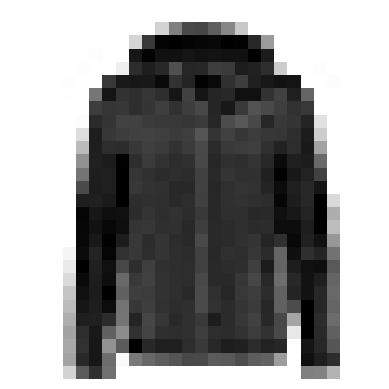

In [36]:
plt.imshow(X_train[0], cmap="binary")
plt.axis('off')
plt.show()

Os rótulos são os IDs das classes (representados como uint8), de 0 a 9:

In [37]:
y_train

array([4, 0, 7, ..., 3, 0, 5], shape=(55000,), dtype=uint8)

Aqui estão os nomes das classes correspondentes:

In [38]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

Então a primeira imagem no conjunto de treinamento é um casaco:

In [19]:
class_names[y_train[0]]

'Coat'

O conjunto de validação contém 5.000 imagens, e o conjunto de teste contém 10.000 imagens:

In [39]:
X_valid.shape

(5000, 28, 28)

In [40]:
X_test.shape

(10000, 28, 28)

Vamos dar uma olhada em uma amostra das imagens no dataset:

Salvando figura 'fashion_mnist_plot' em: c:\welligton-pos-IA\aprendizado_maquina\Apredizado-de-maquinae-livro\images\ann\fashion_mnist_plot.png
✓ Figura salva com sucesso!


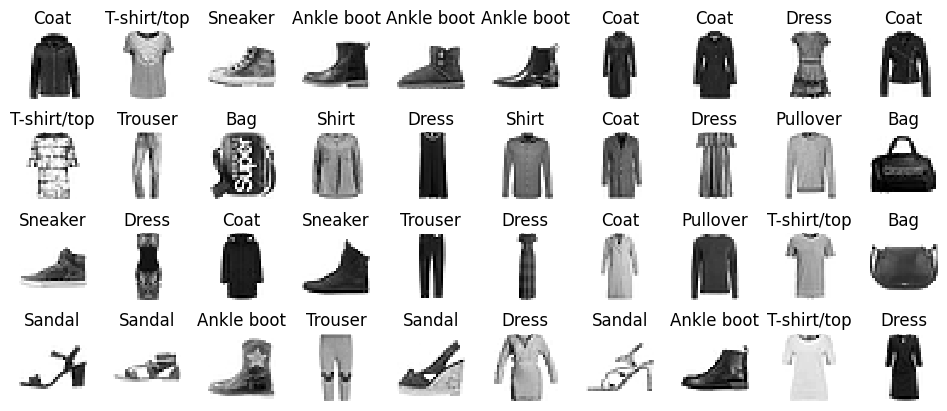

In [42]:
# Define o número de linhas na grade de visualização
n_rows = 4

# Define o número de colunas na grade de visualização
n_cols = 10

# Cria uma figura com tamanho proporcional ao número de linhas e colunas
# Cada imagem terá aproximadamente 1.2x1.2 polegadas
plt.figure(figsize=(n_cols * 1.2, n_rows * 1.2))

# Loop através das linhas da grade
for row in range(n_rows):
    # Loop através das colunas da grade
    for col in range(n_cols):
        # Calcula o índice linear da imagem (0 a 39 neste caso)
        index = n_cols * row + col
        
        # Cria um subplot na posição especificada
        # Posições começam em 1, não em 0
        plt.subplot(n_rows, n_cols, index + 1)
        
        # Exibe a imagem em escala de cinza com interpolação suave
        # cmap="binary": usa mapa de cores preto e branco
        # interpolation="nearest": mantém pixels nítidos sem suavização
        plt.imshow(X_train[index], cmap="binary", interpolation="nearest")
        
        # Remove os eixos (números e marcações) para visualização mais limpa
        plt.axis('off')
        
        # Adiciona o nome da classe como título acima de cada imagem
        plt.title(class_names[y_train[index]], fontsize=12)

# Ajusta o espaçamento entre os subplots
# wspace: espaçamento horizontal (largura)
# hspace: espaçamento vertical (altura)
plt.subplots_adjust(wspace=0.2, hspace=0.5)

# Salva a figura (tight_layout=False para respeitar o ajuste manual de espaçamento)
save_fig('fashion_mnist_plot', tight_layout=False)

# Exibe a grade de imagens
plt.show()

## Explicação da Visualização

### Estrutura
- **Grade**: 4 linhas × 10 colunas = 40 imagens
- **Propósito**: Visualizar uma amostra representativa do dataset de treinamento

### Características
- Cada imagem é exibida em **escala de cinza** (preto e branco)
- O **título** acima de cada imagem mostra a classe da peça de roupa
- Os **eixos são removidos** para uma visualização mais limpa e focada nas imagens
- **Espaçamento ajustado** entre as imagens para melhor legibilidade

### Resultado
Esta visualização permite verificar rapidamente:
- A qualidade das imagens no dataset
- A variedade de peças de roupa
- Se os rótulos estão corretos
- A diversidade visual dentro de cada categoria

In [44]:
# Cria um modelo sequencial (camadas empilhadas uma após a outra)
model = keras.models.Sequential()

# Camada de entrada: achata (flatten) a imagem 28x28 em um vetor de 784 elementos
# Transforma matriz 2D (28, 28) em vetor 1D (784,)
model.add(keras.layers.Flatten(input_shape=[28, 28]))

# Primeira camada oculta: 300 neurônios com função de ativação ReLU
# ReLU ajuda a capturar relações não-lineares nos dados
model.add(keras.layers.Dense(300, activation="relu"))

# Segunda camada oculta: 100 neurônios com função de ativação ReLU
# Reduz progressivamente a dimensionalidade antes da saída
model.add(keras.layers.Dense(100, activation="relu"))

# Camada de saída: 10 neurônios (uma para cada classe de roupa) com ativação softmax
# Softmax converte as saídas em probabilidades que somam 1
# Cada neurônio representa a probabilidade de pertencer a uma das 10 classes
model.add(keras.layers.Dense(10, activation="softmax"))

## Arquitetura da Rede Neural

### Estrutura do Modelo
```
Entrada (28×28 pixels)
    ↓
[Flatten] → 784 neurônios
    ↓
[Dense] → 300 neurônios (ReLU)
    ↓
[Dense] → 100 neurônios (ReLU)
    ↓
[Dense] → 10 neurônios (Softmax)
    ↓
Saída (probabilidades para 10 classes)
```

### Detalhes de Cada Camada

1. **Flatten (Achatamento)**
   - Converte imagem 2D em vetor 1D
   - 28 × 28 = 784 valores de entrada

2. **Camada Oculta 1**
   - 300 neurônios
   - ReLU: mantém valores positivos, zera negativos
   - Total de pesos: 784 × 300 = 235.200

3. **Camada Oculta 2**
   - 100 neurônios
   - ReLU: continua a extração de características
   - Total de pesos: 300 × 100 = 30.000

4. **Camada de Saída**
   - 10 neurônios (um para cada classe)
   - Softmax: normaliza saídas em probabilidades (soma = 1)
   - Total de pesos: 100 × 10 = 1.000

### Total de Parâmetros Treináveis
- Pesos: ~266.200
- Bias: 300 + 100 + 10 = 410
- **Total: ~266.610 parâmetros**

In [24]:
keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

In [25]:
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="relu"),
    keras.layers.Dense(100, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

## Arquitetura da Rede Neural

### Estrutura do Modelo
```
Entrada (28×28 pixels)
    ↓
[Flatten] → 784 neurônios
    ↓
[Dense] → 300 neurônios (ReLU)
    ↓
[Dense] → 100 neurônios (ReLU)
    ↓
[Dense] → 10 neurônios (Softmax)
    ↓
Saída (probabilidades para 10 classes)
```

### Detalhes de Cada Camada

1. **Flatten (Achatamento)**
   - Converte imagem 2D em vetor 1D
   - 28 × 28 = 784 valores de entrada

2. **Camada Oculta 1**
   - 300 neurônios
   - ReLU: mantém valores positivos, zera negativos
   - Total de pesos: 784 × 300 = 235.200

3. **Camada Oculta 2**
   - 100 neurônios
   - ReLU: continua a extração de características
   - Total de pesos: 300 × 100 = 30.000

4. **Camada de Saída**
   - 10 neurônios (um para cada classe)
   - Softmax: normaliza saídas em probabilidades (soma = 1)
   - Total de pesos: 100 × 10 = 1.000

### Total de Parâmetros Treináveis
- Pesos: ~266.200
- Bias: 300 + 100 + 10 = 410
- **Total: ~266.610 parâmetros**

In [47]:
# Retorna uma lista contendo todas as camadas do modelo sequencial
# Útil para inspecionar a arquitetura e acessar propriedades de cada camada
model.layers

[<Flatten name=flatten_1, built=True>,
 <Dense name=dense_3, built=True>,
 <Dense name=dense_4, built=True>,
 <Dense name=dense_5, built=True>]

## Saída Esperada

Ao executar `model.layers`, você verá uma lista similar a:
```python
[<keras.layers.core.Flatten at 0x...>,
 <keras.layers.core.Dense at 0x...>,
 <keras.layers.core.Dense at 0x...>,
 <keras.layers.core.Dense at 0x...>]
```

### Informações Úteis

Você pode acessar propriedades individuais de cada camada:
```python
# Nome da primeira camada
model.layers[0].name  # 'flatten'

# Parâmetros da segunda camada (primeira Dense)
model.layers[1].get_weights()  # retorna [pesos, bias]

# Configuração de uma camada específica
model.layers[2].get_config()  # dicionário com configurações
```

### Usos Comuns
- **Inspeção**: verificar a ordem e tipo das camadas
- **Debugging**: identificar problemas na arquitetura
- **Modificação**: acessar e modificar camadas específicas
- **Transfer Learning**: congelar ou descongelar camadas

In [49]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

## Saída Esperada do `model.summary()`
```
Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
=================================================================
flatten (Flatten)            (None, 784)               0         
_________________________________________________________________
dense (Dense)                (None, 300)               235500    
_________________________________________________________________
dense_1 (Dense)              (None, 100)               30100     
_________________________________________________________________
dense_2 (Dense)              (None, 10)                1010      
=================================================================
Total params: 266,610
Trainable params: 266,610
Non-trainable params: 0
_________________________________________________________________
```

## Interpretação do Resumo

### Colunas
- **Layer (type)**: Nome e tipo de cada camada
- **Output Shape**: Dimensão da saída (None = tamanho do batch variável)
- **Param #**: Número de parâmetros treináveis na camada

### Cálculo dos Parâmetros

1. **Flatten**: 0 parâmetros (apenas reorganiza dados)

2. **Dense (300 neurônios)**:
   - Pesos: 784 × 300 = 235.200
   - Bias: 300
   - **Total**: 235.500

3. **Dense (100 neurônios)**:
   - Pesos: 300 × 100 = 30.000
   - Bias: 100
   - **Total**: 30.100

4. **Dense (10 neurônios)**:
   - Pesos: 100 × 10 = 1.000
   - Bias: 10
   - **Total**: 1.010

### Totais
- **Total params**: 266.610 parâmetros
- **Trainable params**: 266.610 (todos treináveis)
- **Non-trainable params**: 0 (nenhum congelado)

### Utilidade
O `summary()` é essencial para:
- ✓ Verificar se a arquitetura está correta
- ✓ Identificar o número total de parâmetros
- ✓ Detectar problemas de dimensionalidade
- ✓ Estimar requisitos de memória

In [51]:
# Cria uma visualização gráfica da arquitetura do modelo e salva como imagem PNG
# 
# Parâmetros:
# - model: o modelo neural a ser visualizado
# - "my_fashion_mnist_model.png": nome do arquivo onde a imagem será salva
# - show_shapes=True: exibe as dimensões de entrada/saída de cada camada no diagrama
#
# Esta função gera um diagrama que mostra:
# - Cada camada como uma caixa com seu nome e tipo
# - Conexões entre as camadas (setas)
# - Formas/dimensões dos dados em cada etapa (quando show_shapes=True)
#
# Útil para:
# 1. Documentação visual do modelo
# 2. Apresentações e relatórios
# 3. Compartilhar arquitetura com equipe
# 4. Verificar visualmente o fluxo de dados pela rede
#
# Nota: Requer a biblioteca 'pydot' e 'graphviz' instalados no sistema
keras.utils.plot_model(model, "my_fashion_mnist_model.png", show_shapes=True)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [53]:
# Obtém referência à segunda camada do modelo (índice 1)
# Neste caso, é a primeira camada Dense com 300 neurônios
hidden1 = model.layers[1]

# Retorna o nome atribuído automaticamente à camada
# Geralmente será algo como 'dense', 'dense_0', etc.
hidden1.name

'dense_3'

In [54]:
# Verifica se o método get_layer() retorna exatamente a mesma referência de objeto
# 
# model.get_layer(hidden1.name): busca a camada pelo nome
# 'is': operador que verifica identidade de objeto (mesma posição na memória)
# hidden1: referência à camada obtida anteriormente via model.layers[1]
#
# Retorna True porque ambas as variáveis apontam para o mesmo objeto na memória
# Isso confirma que get_layer() retorna a referência original, não uma cópia
model.get_layer(hidden1.name) is hidden1

True

In [55]:
# Obtém os pesos e bias da camada oculta
# 
# get_weights() retorna uma lista com dois arrays NumPy:
# 1. weights: matriz de pesos da camada (conexões entre neurônios)
# 2. biases: vetor de bias (um valor para cada neurônio da camada)
#
# Para a camada hidden1 (Dense com 300 neurônios conectada a entrada de 784):
# - weights terá forma (784, 300): 784 entradas × 300 neurônios
# - biases terá forma (300,): um bias para cada um dos 300 neurônios
#
# Estes são os parâmetros treináveis que a rede ajusta durante o treinamento
# para aprender a mapear entradas para saídas corretas
weights, biases = hidden1.get_weights()

In [56]:
# Exibe a matriz completa de pesos da camada hidden1
# 
# Mostrará um array NumPy de forma (784, 300) contendo:
# - 784 linhas (uma para cada pixel da imagem de entrada achatada)
# - 300 colunas (uma para cada neurônio da camada)
# 
# Os valores são números de ponto flutuante (geralmente entre -1 e 1)
# inicializados aleatoriamente usando o inicializador padrão do Keras
#
# A saída será truncada por ser muito grande para exibir completamente
# NumPy mostrará algo como:
# array([[ 0.0234, -0.0512, ...,  0.0891],
#        [-0.0423,  0.0765, ..., -0.0234],
#        ...
#        [ 0.0567, -0.0123, ...,  0.0445]])
weights

array([[-0.04108438,  0.03891496, -0.03143256, ...,  0.05769524,
         0.02300419,  0.03101925],
       [ 0.03596032, -0.05176051,  0.01169377, ...,  0.02672699,
        -0.0707823 ,  0.0522431 ],
       [-0.03792603, -0.00812622,  0.04814377, ...,  0.04086681,
        -0.00046826, -0.01698025],
       ...,
       [ 0.00386586, -0.03671988,  0.02358846, ..., -0.05786216,
         0.03276561,  0.07154877],
       [-0.04430544, -0.03008161,  0.03912921, ...,  0.04396852,
         0.05739862, -0.04054653],
       [ 0.03273677, -0.00733607, -0.00933202, ...,  0.06318346,
         0.07315676, -0.01108477]], shape=(784, 300), dtype=float32)

In [57]:
# Retorna as dimensões da matriz de pesos
# 
# shape é um atributo que mostra o formato do array NumPy
# Para a camada hidden1:
# - Primeira dimensão (784): número de entradas (pixels da imagem achatada)
# - Segunda dimensão (300): número de neurônios na camada
#
# Cada peso conecta um pixel de entrada a um neurônio específico
# Total de conexões: 784 × 300 = 235.200 pesos
weights.shape

(784, 300)

In [59]:
# Exibe o vetor de bias da camada hidden1
# 
# Mostrará um array NumPy 1D de forma (300,) contendo:
# - Um valor de bias para cada um dos 300 neurônios da camada
# 
# Os bias são valores adicionados à soma ponderada das entradas antes da ativação
# Por padrão no Keras, são inicializados com zeros
#
# A saída será algo como:
# array([0., 0., 0., ..., 0., 0., 0.], dtype=float32)
# ou, se o modelo já foi treinado, terá valores diferentes de zero
biases

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [60]:
# Retorna as dimensões do vetor de bias
# 
# shape é um atributo que mostra o formato do array NumPy
# Para a camada hidden1 com 300 neurônios:
# - (300,) indica um vetor unidimensional com 300 elementos
# 
# Cada bias corresponde a um neurônio da camada
# O bias é somado à saída ponderada antes da função de ativação
biases.shape

(300,)

In [61]:
# Configura o modelo para treinamento, definindo função de perda, otimizador e métricas
#
# Parâmetros:
# 
# loss="sparse_categorical_crossentropy":
#   - Função de perda para classificação multiclasse (10 classes)
#   - "sparse" porque os rótulos são inteiros (0-9), não one-hot encoded
#   - Mede quão longe as previsões estão dos valores reais
#   - Quanto menor a perda, melhor o modelo
#
# optimizer="sgd":
#   - SGD (Stochastic Gradient Descent) - Descida do Gradiente Estocástica
#   - Algoritmo que atualiza os pesos para minimizar a perda
#   - Versão básica, existem variantes mais sofisticadas (Adam, RMSprop)
#
# metrics=["accuracy"]:
#   - Métrica adicional para acompanhar durante o treinamento
#   - Accuracy = % de previsões corretas
#   - Não afeta o treinamento, apenas monitora o desempenho
#
# Nota: compile() deve ser chamado antes de fit() (treinar o modelo)
model.compile(loss="sparse_categorical_crossentropy",
              optimizer="sgd",
              metrics=["accuracy"])

## Explicação Detalhada da Compilação

### 1. Função de Perda (Loss Function)

**`sparse_categorical_crossentropy`**
```python
# Quando usar cada tipo:

# sparse_categorical_crossentropy
y_true = [0, 1, 2, 3]  # Labels como inteiros
# Use quando: rótulos são inteiros (0 a num_classes-1)

# categorical_crossentropy  
y_true = [[1,0,0], [0,1,0], [0,0,1], [1,0,0]]  # One-hot encoded
# Use quando: rótulos são vetores one-hot
```

**Por que "sparse"?**
- Economiza memória: armazena 1 inteiro em vez de 10 valores
- Mais eficiente para muitas classes
- Resultado matemático idêntico

### 2. Otimizador (Optimizer)

**`sgd` - Stochastic Gradient Descent**
```python
# Fórmula básica:
peso_novo = peso_atual - taxa_aprendizado × gradiente
```

**Características:**
- ✓ Simples e confiável
- ✓ Bom para entender conceitos
- ✗ Convergência pode ser lenta
- ✗ Sensível à taxa de aprendizado

**Alternativas mais avançadas:**
```python
# Adam (mais popular atualmente)
optimizer="adam"

# RMSprop (boa para RNNs)
optimizer="rmsprop"

# SGD com momentum
optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)
```

### 3. Métricas (Metrics)

**`accuracy` - Acurácia**
```python
# Fórmula:
accuracy = previsões_corretas / total_previsões

# Exemplo:
# 100 imagens testadas
# 92 classificadas corretamente
# Accuracy = 92/100 = 92%
```

**Outras métricas úteis:**
```python
metrics=["accuracy", "top_k_categorical_accuracy"]
# top_k: considera correto se classe real está entre top-k previsões
```

### Resumo do Processo
```
1. compile() → Prepara o modelo
   ↓
2. fit() → Treina o modelo
   ↓
   Para cada batch:
   a) Forward pass: calcula previsões
   b) Calcula loss (sparse_categorical_crossentropy)
   c) Backward pass: calcula gradientes
   d) Optimizer (SGD) atualiza pesos
   e) Calcula accuracy para monitoramento
   ↓
3. evaluate() → Testa o modelo
```

### Configuração Completa (Alternativa)
```python
# Versão mais explícita com parâmetros personalizados
model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(),
    optimizer=keras.optimizers.SGD(learning_rate=0.01),
    metrics=[
        keras.metrics.SparseCategoricalAccuracy(name="accuracy"),
        keras.metrics.TopKCategoricalAccuracy(k=3, name="top_3_accuracy")
    ]
)
```

### Por que esta configuração?

Para o Fashion MNIST:
- ✓ **10 classes**: sparse_categorical_crossentropy é perfeito
- ✓ **Dataset simples**: SGD é suficiente (não precisa Adam)
- ✓ **Accuracy**: métrica intuitiva para classificação

This is equivalent to:

```python
model.compile(loss=keras.losses.sparse_categorical_crossentropy,
              optimizer=keras.optimizers.SGD(),
              metrics=[keras.metrics.sparse_categorical_accuracy])
```

In [62]:
# Treina o modelo neural com os dados de treinamento
#
# Parâmetros:
#
# X_train: imagens de treinamento (55.000 imagens de 28×28 pixels normalizadas)
# y_train: rótulos de treinamento (valores de 0 a 9)
#
# epochs=30:
#   - Número de vezes que o modelo percorre TODO o conjunto de treinamento
#   - Em cada época, o modelo vê todas as 55.000 imagens
#   - Mais épocas = mais tempo de treinamento = potencialmente melhor desempenho
#   - Cuidado: muitas épocas podem causar overfitting
#
# validation_data=(X_valid, y_valid):
#   - Dados de validação para avaliar o modelo após cada época
#   - Não são usados para treinar, apenas para monitorar o desempenho
#   - Ajuda a detectar overfitting (treino melhora, validação piora)
#   - X_valid: 5.000 imagens de validação
#   - y_valid: 5.000 rótulos de validação
#
# Retorno:
# history: objeto contendo histórico do treinamento
#   - history.history['loss']: perda no treino por época
#   - history.history['accuracy']: acurácia no treino por época  
#   - history.history['val_loss']: perda na validação por época
#   - history.history['val_accuracy']: acurácia na validação por época
#
# Durante o treinamento, você verá algo como:
# Epoch 1/30
# 1719/1719 [==============================] - 3s - loss: 0.7123 - accuracy: 0.7589 - val_loss: 0.5234 - val_accuracy: 0.8234
history = model.fit(X_train, y_train, epochs=30,
                    validation_data=(X_valid, y_valid))

Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.7589 - loss: 0.7342 - val_accuracy: 0.8260 - val_loss: 0.5128
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8300 - loss: 0.4888 - val_accuracy: 0.8364 - val_loss: 0.4590
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8451 - loss: 0.4447 - val_accuracy: 0.8580 - val_loss: 0.4164
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8524 - loss: 0.4191 - val_accuracy: 0.8638 - val_loss: 0.3976
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8615 - loss: 0.3979 - val_accuracy: 0.8664 - val_loss: 0.3863
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8647 - loss: 0.3842 - val_accuracy: 0.8636 - val_loss: 0.3820
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8703 - loss: 0.3695 - val_accuracy: 0.8702 - val_loss: 0.3744
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8731 - loss: 0.3588 - 

### Interpretação das Métricas

**loss** (perda de treinamento):
- Deve **diminuir** ao longo das épocas
- Indica quão bem o modelo se ajusta aos dados de treino

**accuracy** (acurácia de treinamento):
- Deve **aumentar** ao longo das épocas
- % de previsões corretas no conjunto de treino

**val_loss** (perda de validação):
- Deve **diminuir** idealmente
- Se começar a subir enquanto loss desce → overfitting

**val_accuracy** (acurácia de validação):
- Deve **aumentar** idealmente
- Métrica mais importante: desempenho em dados não vistos

### Sinais de Problemas
```python

In [63]:
# Retorna um dicionário com os parâmetros de configuração do treinamento
#
# Contém informações sobre:
# - verbose: nível de detalhamento das mensagens durante treinamento
# - epochs: número total de épocas executadas
# - steps: número de batches por época
# - samples: número total de amostras de treinamento
# - do_validation: se validação foi executada
# - metrics: lista de métricas monitoradas
#
# Útil para:
# 1. Verificar configurações usadas no treinamento
# 2. Documentar experimentos
# 3. Reproduzir treinamentos
# 4. Debugging de problemas de treinamento
history.params

{'verbose': 'auto', 'epochs': 30, 'steps': 1719}

In [64]:
# Imprime a lista de todas as épocas executadas durante o treinamento
#
# history.epoch contém os índices das épocas (começando do 0)
# Se foram executadas 30 épocas, mostrará [0, 1, 2, ..., 29]
#
# Útil para:
# - Verificar quantas épocas realmente foram executadas
# - Confirmar que o treinamento completou todas as épocas
# - Identificar se early stopping interrompeu antes do final
print(history.epoch)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]


In [66]:
# Retorna as chaves (nomes das métricas) do dicionário history.history
#
# history.history é um dicionário onde:
# - Chaves: nomes das métricas monitoradas
# - Valores: listas com os valores da métrica em cada época
#
# Para nosso modelo, as chaves são:
# - 'loss': perda de treinamento por época
# - 'accuracy': acurácia de treinamento por época
# - 'val_loss': perda de validação por época
# - 'val_accuracy': acurácia de validação por época
#
# Útil para verificar quais métricas foram registradas durante o treinamento
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

Salvando figura 'keras_learning_curves_plot' em: c:\welligton-pos-IA\aprendizado_maquina\Apredizado-de-maquinae-livro\images\ann\keras_learning_curves_plot.png
✓ Figura salva com sucesso!


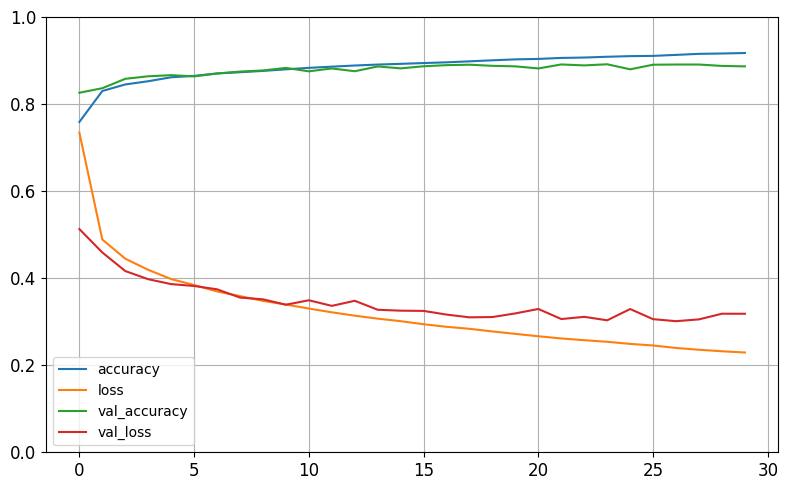

In [70]:
# Importa a biblioteca pandas para manipulação de dados
import pandas as pd

# Converte o dicionário history.history em um DataFrame pandas e plota todas as colunas
# history.history contém: {'loss': [...], 'accuracy': [...], 'val_loss': [...], 'val_accuracy': [...]}
# O DataFrame facilita a plotagem de todas as métricas de uma vez
# figsize=(8, 5): define o tamanho da figura em polegadas (largura, altura)
pd.DataFrame(history.history).plot(figsize=(8, 5))

# Adiciona uma grade ao gráfico para facilitar a leitura dos valores
plt.grid(True)

# Define o limite do eixo Y entre 0 e 1
# gca() = "get current axes" (obtém os eixos atuais do gráfico)
# set_ylim(0, 1): útil porque accuracy e loss normalizadas ficam entre 0 e 1
plt.gca().set_ylim(0, 1)

# Salva a figura como arquivo PNG usando a função personalizada definida anteriormente
save_fig("keras_learning_curves_plot")

# Exibe o gráfico na tela
plt.show()

## Visualização Resultante

O gráfico mostrará **4 curvas** no mesmo plot:

### Legendas
- **loss** (azul): Perda de treinamento - deve diminuir
- **accuracy** (laranja): Acurácia de treinamento - deve aumentar
- **val_loss** (verde): Perda de validação - deve diminuir
- **val_accuracy** (vermelho): Acurácia de validação - deve aumentar

### Interpretação do Gráfico

**Cenário Ideal:**
```
1.0 ┤                    ╭─ accuracy
    │                  ╭─╯
    │                ╭─╯
0.5 ┤              ╭─╯        ╭─ val_accuracy
    │            ╭─╯         ╭─╯
    │    loss ╮ ╱      val_loss
0.0 ┼─────────╰╯──────────────────────
    0         10         20         30
                    Épocas
```

**Sinais no Gráfico:**

✅ **Bom (não há overfitting):**
- Loss de treino e validação decrescem juntas
- Accuracy de treino e validação crescem juntas
- Curvas próximas umas das outras

⚠️ **Overfitting:**
- Loss de treino continua caindo
- Loss de validação começa a subir
- Gap grande entre treino e validação

🔴 **Underfitting:**
- Todas as curvas param de melhorar cedo
- Valores ruins (loss alto, accuracy baixo)

### Estrutura do DataFrame
```python
# Antes de plotar, o DataFrame se parece com:
print(pd.DataFrame(history.history).head())

#       loss  accuracy  val_loss  val_accuracy
# 0  0.7123    0.7589    0.5234        0.8234
# 1  0.5012    0.8234    0.4567        0.8456
# 2  0.4234    0.8567    0.4123        0.8567
# 3  0.3789    0.8723    0.3890        0.8678
# 4  0.3456    0.8834    0.3712        0.8745
```

### Vantagens do Método pandas

1. **Conciso**: Uma linha plota 4 curvas
2. **Automático**: Legendas e cores geradas automaticamente
3. **Fácil**: Não precisa especificar cada métrica individualmente

### Alternativa Mais Detalhada

In [71]:
# Avalia o modelo treinado no conjunto de teste (dados não vistos)
# 
# Parâmetros:
# - X_test: 10.000 imagens de teste (28×28 pixels normalizadas)
# - y_test: rótulos verdadeiros (0 a 9)
#
# Processo:
# 1. Faz predições para todas as imagens de teste
# 2. Calcula a função de perda (sparse_categorical_crossentropy)
# 3. Calcula a métrica de acurácia (% de acertos)
#
# Retorno:
# Lista [test_loss, test_accuracy]
# Exemplo: [0.3456, 0.8723] significa:
#   - Loss = 0.3456 (quanto menor, melhor)
#   - Accuracy = 0.8723 (87.23% de acertos)
#
# Esta é a avaliação final do modelo em dados completamente novos
# que não foram usados durante treinamento ou validação
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8727 - loss: 0.3541


[0.35412919521331787, 0.8726999759674072]

In [72]:
# Seleciona as 3 primeiras imagens do conjunto de teste para fazer predições
# X_new terá forma (3, 28, 28) - 3 imagens de 28×28 pixels
X_new = X_test[:3]

# Faz predições para as 3 imagens
# model.predict() retorna as probabilidades para cada uma das 10 classes
# y_proba terá forma (3, 10) - 3 amostras × 10 probabilidades (uma por classe)
# Cada linha soma 1.0 (100%) devido à função softmax na camada de saída
y_proba = model.predict(X_new)

# Arredonda as probabilidades para 2 casas decimais para melhor visualização
# Facilita a leitura das probabilidades
# Exemplo: 0.8934567 → 0.89 (89% de confiança)
y_proba.round(2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


array([[0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.01, 0.  , 0.99],
       [0.  , 0.  , 1.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 1.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ]],
      dtype=float32)

**Aviso**: `model.predict_classes(X_new)` está obsoleto. Foi substituído por `np.argmax(model.predict(X_new), axis=-1)`.

In [73]:
# ❌ Método ANTIGO e DEPRECIADO (não usar mais)
# y_pred = model.predict_classes(X_new)

# ✅ Método ATUAL e RECOMENDADO
# Faz predições e converte probabilidades em classes
# 
# Processo em 2 etapas:
# 1. model.predict(X_new): retorna matriz de probabilidades (3, 10)
#    Cada linha contém 10 probabilidades (uma para cada classe)
# 
# 2. np.argmax(..., axis=-1): encontra o índice da maior probabilidade em cada linha
#    axis=-1 significa "ao longo da última dimensão" (as colunas/classes)
#    Retorna um array 1D com os índices das classes preditas
#
# Exemplo:
# Se y_proba[0] = [0.00, 0.00, 0.00, ..., 0.97] (classe 9 tem 97%)
# Então y_pred[0] = 9
y_pred = np.argmax(model.predict(X_new), axis=-1)

# Exibe as classes preditas como array de inteiros
# Exemplo de saída: array([9, 2, 1])
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


array([9, 2, 1])

In [75]:
# Converte os índices das classes preditas em nomes legíveis
#
# Processo:
# 1. np.array(class_names): converte a lista de nomes em array NumPy
#    ['T-shirt/top', 'Trouser', 'Pullover', ..., 'Ankle boot']
#
# 2. [y_pred]: usa indexação avançada do NumPy
#    y_pred = [9, 2, 1]
#    Retorna os elementos nos índices 9, 2 e 1 do array
#
# Exemplo:
# class_names[9] = 'Ankle boot'
# class_names[2] = 'Pullover'
# class_names[1] = 'Trouser'
#
# Resultado: array com os nomes das classes preditas
# array(['Ankle boot', 'Pullover', 'Trouser'])
#
# Esta é uma forma elegante e vetorizada de mapear índices → nomes
np.array(class_names)[y_pred]

array(['Ankle boot', 'Pullover', 'Trouser'], dtype='<U11')

In [76]:
# Seleciona os 3 primeiros rótulos (classes verdadeiras) do conjunto de teste
# Estes são os valores reais/corretos das imagens em X_new
#
# y_test contém os rótulos de todas as 10.000 imagens de teste (valores de 0 a 9)
# [:3] pega apenas os 3 primeiros elementos
#
# Usado para comparar as predições do modelo (y_pred) com os valores reais (y_new)
# e verificar se o modelo acertou ou errou
#
# Exemplo de saída: array([9, 2, 1])
# Significa que as 3 primeiras imagens são:
#   - Imagem 1: classe 9 (Ankle boot)
#   - Imagem 2: classe 2 (Pullover)
#   - Imagem 3: classe 1 (Trouser)
y_new = y_test[:3]

# Exibe os rótulos verdadeiros
y_new

array([9, 2, 1], dtype=uint8)

Salvando figura 'fashion_mnist_images_plot' em: c:\welligton-pos-IA\aprendizado_maquina\Apredizado-de-maquinae-livro\images\ann\fashion_mnist_images_plot.png
✓ Figura salva com sucesso!


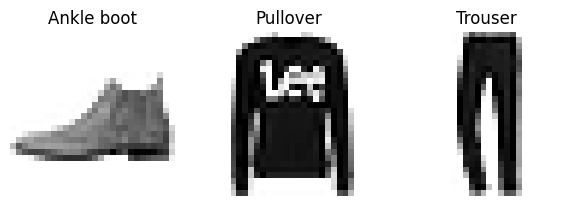

In [77]:
# Cria uma figura com tamanho 7.2 x 2.4 polegadas
plt.figure(figsize=(7.2, 2.4))

# Loop através das 3 imagens em X_new
for index, image in enumerate(X_new):
    # Cria um subplot na grade 1x3 (1 linha, 3 colunas)
    # index + 1 porque subplots começam em 1, não em 0
    plt.subplot(1, 3, index + 1)
    
    # Exibe a imagem em escala de cinza
    # cmap="binary": mapa de cores preto e branco
    # interpolation="nearest": mantém pixels nítidos sem suavização
    plt.imshow(image, cmap="binary", interpolation="nearest")
    
    # Remove os eixos (números e marcações) para visualização limpa
    plt.axis('off')
    
    # Adiciona o nome da classe real como título
    # y_test[index] retorna o número da classe (0-9)
    # class_names[...] converte para o nome legível
    plt.title(class_names[y_test[index]], fontsize=12)

# Ajusta o espaçamento entre os subplots
# wspace=0.2: espaçamento horizontal (20% da largura média dos subplots)
# hspace=0.5: espaçamento vertical (50% da altura média dos subplots)
plt.subplots_adjust(wspace=0.2, hspace=0.5)

# Salva a figura sem aplicar tight_layout (usa o ajuste manual acima)
save_fig('fashion_mnist_images_plot', tight_layout=False)

# Exibe o gráfico na tela
plt.show()

# Regression MLP

Let's load, split and scale the California housing dataset (the original one, not the modified one as in chapter 2):

In [48]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

housing = fetch_california_housing()

X_train_full, X_test, y_train_full, y_test = train_test_split(housing.data, housing.target, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full, y_train_full, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)
X_test = scaler.transform(X_test)

In [49]:
np.random.seed(42)
tf.random.set_seed(42)

In [50]:
model = keras.models.Sequential([
    keras.layers.Dense(30, activation="relu", input_shape=X_train.shape[1:]),
    keras.layers.Dense(1)
])
model.compile(loss="mean_squared_error", optimizer=keras.optimizers.SGD(learning_rate=1e-3))
history = model.fit(X_train, y_train, epochs=20, validation_data=(X_valid, y_valid))
mse_test = model.evaluate(X_test, y_test)
X_new = X_test[:3]
y_pred = model.predict(X_new)

Epoch 1/20
363/363 [==============================] - 0s 893us/step - loss: 2.2656 - val_loss: 0.8560
Epoch 2/20
363/363 [==============================] - 0s 670us/step - loss: 0.7413 - val_loss: 0.6531
Epoch 3/20
363/363 [==============================] - 0s 661us/step - loss: 0.6604 - val_loss: 0.6099
Epoch 4/20
363/363 [==============================] - 0s 640us/step - loss: 0.6245 - val_loss: 0.5658
Epoch 5/20
363/363 [==============================] - 0s 688us/step - loss: 0.5770 - val_loss: 0.5355
Epoch 6/20
363/363 [==============================] - 0s 668us/step - loss: 0.5609 - val_loss: 0.5173
Epoch 7/20
363/363 [==============================] - 0s 667us/step - loss: 0.5500 - val_loss: 0.5081
Epoch 8/20
363/363 [==============================] - 0s 647us/step - loss: 0.5200 - val_loss: 0.4799
Epoch 9/20
363/363 [==============================] - 0s 683us/step - loss: 0.5051 - val_loss: 0.4690
Epoch 10/20
363/363 [==============================] - 0s 679us/step - loss: 0.491

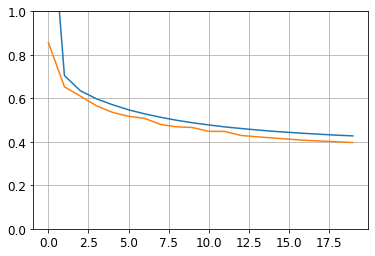

In [51]:
plt.plot(pd.DataFrame(history.history))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.show()

In [52]:
y_pred

array([[0.3885664],
       [1.6792021],
       [3.1022797]], dtype=float32)

# Functional API

Not all neural network models are simply sequential. Some may have complex topologies. Some may have multiple inputs and/or multiple outputs. For example, a Wide & Deep neural network (see [paper](https://ai.google/research/pubs/pub45413)) connects all or part of the inputs directly to the output layer.

In [53]:
np.random.seed(42)
tf.random.set_seed(42)

In [54]:
input_ = keras.layers.Input(shape=X_train.shape[1:])
hidden1 = keras.layers.Dense(30, activation="relu")(input_)
hidden2 = keras.layers.Dense(30, activation="relu")(hidden1)
concat = keras.layers.concatenate([input_, hidden2])
output = keras.layers.Dense(1)(concat)
model = keras.models.Model(inputs=[input_], outputs=[output])

In [55]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 8)]          0                                            
__________________________________________________________________________________________________
dense_5 (Dense)                 (None, 30)           270         input_1[0][0]                    
__________________________________________________________________________________________________
dense_6 (Dense)                 (None, 30)           930         dense_5[0][0]                    
__________________________________________________________________________________________________
concatenate (Concatenate)       (None, 38)           0           input_1[0][0]                    
                                                                 dense_6[0][0]                

In [56]:
model.compile(loss="mean_squared_error", optimizer=keras.optimizers.SGD(learning_rate=1e-3))
history = model.fit(X_train, y_train, epochs=20,
                    validation_data=(X_valid, y_valid))
mse_test = model.evaluate(X_test, y_test)
y_pred = model.predict(X_new)

Epoch 1/20
363/363 [==============================] - 1s 887us/step - loss: 1.9731 - val_loss: 3.3940
Epoch 2/20
363/363 [==============================] - 0s 683us/step - loss: 0.7638 - val_loss: 0.9360
Epoch 3/20
363/363 [==============================] - 0s 687us/step - loss: 0.6045 - val_loss: 0.5649
Epoch 4/20
363/363 [==============================] - 0s 709us/step - loss: 0.5862 - val_loss: 0.5712
Epoch 5/20
363/363 [==============================] - 0s 707us/step - loss: 0.5452 - val_loss: 0.5045
Epoch 6/20
363/363 [==============================] - 0s 672us/step - loss: 0.5243 - val_loss: 0.4831
Epoch 7/20
363/363 [==============================] - 0s 681us/step - loss: 0.5185 - val_loss: 0.4639
Epoch 8/20
363/363 [==============================] - 0s 700us/step - loss: 0.4947 - val_loss: 0.4638
Epoch 9/20
363/363 [==============================] - 0s 675us/step - loss: 0.4782 - val_loss: 0.4421
Epoch 10/20
363/363 [==============================] - 0s 693us/step - loss: 0.470

What if you want to send different subsets of input features through the wide or deep paths? We will send 5 features (features 0 to 4), and 6 through the deep path (features 2 to 7). Note that 3 features will go through both (features 2, 3 and 4).

In [57]:
np.random.seed(42)
tf.random.set_seed(42)

In [58]:
input_A = keras.layers.Input(shape=[5], name="wide_input")
input_B = keras.layers.Input(shape=[6], name="deep_input")
hidden1 = keras.layers.Dense(30, activation="relu")(input_B)
hidden2 = keras.layers.Dense(30, activation="relu")(hidden1)
concat = keras.layers.concatenate([input_A, hidden2])
output = keras.layers.Dense(1, name="output")(concat)
model = keras.models.Model(inputs=[input_A, input_B], outputs=[output])

In [59]:
model.compile(loss="mse", optimizer=keras.optimizers.SGD(learning_rate=1e-3))

X_train_A, X_train_B = X_train[:, :5], X_train[:, 2:]
X_valid_A, X_valid_B = X_valid[:, :5], X_valid[:, 2:]
X_test_A, X_test_B = X_test[:, :5], X_test[:, 2:]
X_new_A, X_new_B = X_test_A[:3], X_test_B[:3]

history = model.fit((X_train_A, X_train_B), y_train, epochs=20,
                    validation_data=((X_valid_A, X_valid_B), y_valid))
mse_test = model.evaluate((X_test_A, X_test_B), y_test)
y_pred = model.predict((X_new_A, X_new_B))

Epoch 1/20
363/363 [==============================] - 1s 934us/step - loss: 3.1941 - val_loss: 0.8072
Epoch 2/20
363/363 [==============================] - 0s 734us/step - loss: 0.7247 - val_loss: 0.6658
Epoch 3/20
363/363 [==============================] - 0s 719us/step - loss: 0.6176 - val_loss: 0.5687
Epoch 4/20
363/363 [==============================] - 0s 718us/step - loss: 0.5799 - val_loss: 0.5296
Epoch 5/20
363/363 [==============================] - 0s 689us/step - loss: 0.5409 - val_loss: 0.4993
Epoch 6/20
363/363 [==============================] - 0s 717us/step - loss: 0.5173 - val_loss: 0.4811
Epoch 7/20
363/363 [==============================] - 0s 708us/step - loss: 0.5186 - val_loss: 0.4696
Epoch 8/20
363/363 [==============================] - 0s 697us/step - loss: 0.4977 - val_loss: 0.4496
Epoch 9/20
363/363 [==============================] - 0s 713us/step - loss: 0.4765 - val_loss: 0.4404
Epoch 10/20
363/363 [==============================] - 0s 723us/step - loss: 0.467

Adding an auxiliary output for regularization:

In [60]:
np.random.seed(42)
tf.random.set_seed(42)

In [61]:
input_A = keras.layers.Input(shape=[5], name="wide_input")
input_B = keras.layers.Input(shape=[6], name="deep_input")
hidden1 = keras.layers.Dense(30, activation="relu")(input_B)
hidden2 = keras.layers.Dense(30, activation="relu")(hidden1)
concat = keras.layers.concatenate([input_A, hidden2])
output = keras.layers.Dense(1, name="main_output")(concat)
aux_output = keras.layers.Dense(1, name="aux_output")(hidden2)
model = keras.models.Model(inputs=[input_A, input_B],
                           outputs=[output, aux_output])

In [62]:
model.compile(loss=["mse", "mse"], loss_weights=[0.9, 0.1], optimizer=keras.optimizers.SGD(learning_rate=1e-3))

In [63]:
history = model.fit([X_train_A, X_train_B], [y_train, y_train], epochs=20,
                    validation_data=([X_valid_A, X_valid_B], [y_valid, y_valid]))

Epoch 1/20
363/363 [==============================] - 1s 1ms/step - loss: 3.4633 - main_output_loss: 3.3289 - aux_output_loss: 4.6732 - val_loss: 1.6233 - val_main_output_loss: 0.8468 - val_aux_output_loss: 8.6117
Epoch 2/20
363/363 [==============================] - 0s 879us/step - loss: 0.9807 - main_output_loss: 0.7503 - aux_output_loss: 3.0537 - val_loss: 1.5163 - val_main_output_loss: 0.6836 - val_aux_output_loss: 9.0109
Epoch 3/20
363/363 [==============================] - 0s 890us/step - loss: 0.7742 - main_output_loss: 0.6290 - aux_output_loss: 2.0810 - val_loss: 1.4639 - val_main_output_loss: 0.6229 - val_aux_output_loss: 9.0326
Epoch 4/20
363/363 [==============================] - 0s 847us/step - loss: 0.6952 - main_output_loss: 0.5897 - aux_output_loss: 1.6449 - val_loss: 1.3388 - val_main_output_loss: 0.5481 - val_aux_output_loss: 8.4552
Epoch 5/20
363/363 [==============================] - 0s 902us/step - loss: 0.6469 - main_output_loss: 0.5508 - aux_output_loss: 1.5118 - 

In [64]:
total_loss, main_loss, aux_loss = model.evaluate(
    [X_test_A, X_test_B], [y_test, y_test])
y_pred_main, y_pred_aux = model.predict([X_new_A, X_new_B])

162/162 [==============================] - 0s 546us/step - loss: 0.4668 - main_output_loss: 0.4178 - aux_output_loss: 0.9082


# The subclassing API

In [65]:
class WideAndDeepModel(keras.models.Model):
    def __init__(self, units=30, activation="relu", **kwargs):
        super().__init__(**kwargs)
        self.hidden1 = keras.layers.Dense(units, activation=activation)
        self.hidden2 = keras.layers.Dense(units, activation=activation)
        self.main_output = keras.layers.Dense(1)
        self.aux_output = keras.layers.Dense(1)
        
    def call(self, inputs):
        input_A, input_B = inputs
        hidden1 = self.hidden1(input_B)
        hidden2 = self.hidden2(hidden1)
        concat = keras.layers.concatenate([input_A, hidden2])
        main_output = self.main_output(concat)
        aux_output = self.aux_output(hidden2)
        return main_output, aux_output

model = WideAndDeepModel(30, activation="relu")

In [66]:
model.compile(loss="mse", loss_weights=[0.9, 0.1], optimizer=keras.optimizers.SGD(learning_rate=1e-3))
history = model.fit((X_train_A, X_train_B), (y_train, y_train), epochs=10,
                    validation_data=((X_valid_A, X_valid_B), (y_valid, y_valid)))
total_loss, main_loss, aux_loss = model.evaluate((X_test_A, X_test_B), (y_test, y_test))
y_pred_main, y_pred_aux = model.predict((X_new_A, X_new_B))

Epoch 1/10
363/363 [==============================] - 1s 1ms/step - loss: 3.3855 - output_1_loss: 3.3304 - output_2_loss: 3.8821 - val_loss: 2.1435 - val_output_1_loss: 1.1581 - val_output_2_loss: 11.0117
Epoch 2/10
363/363 [==============================] - 0s 852us/step - loss: 1.0790 - output_1_loss: 0.9329 - output_2_loss: 2.3942 - val_loss: 1.7567 - val_output_1_loss: 0.8205 - val_output_2_loss: 10.1825
Epoch 3/10
363/363 [==============================] - 0s 885us/step - loss: 0.8644 - output_1_loss: 0.7583 - output_2_loss: 1.8194 - val_loss: 1.5664 - val_output_1_loss: 0.7913 - val_output_2_loss: 8.5419
Epoch 4/10
363/363 [==============================] - 0s 863us/step - loss: 0.7850 - output_1_loss: 0.6979 - output_2_loss: 1.5689 - val_loss: 1.3088 - val_output_1_loss: 0.6549 - val_output_2_loss: 7.1933
Epoch 5/10
363/363 [==============================] - 0s 843us/step - loss: 0.7294 - output_1_loss: 0.6499 - output_2_loss: 1.4452 - val_loss: 1.1357 - val_output_1_loss: 0.596

# Saving and Restoring

In [68]:
np.random.seed(42)
tf.random.set_seed(42)

In [69]:
model = keras.models.Sequential([
    keras.layers.Dense(30, activation="relu", input_shape=[8]),
    keras.layers.Dense(30, activation="relu"),
    keras.layers.Dense(1)
])    

In [70]:
model.compile(loss="mse", optimizer=keras.optimizers.SGD(learning_rate=1e-3))
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_valid, y_valid))
mse_test = model.evaluate(X_test, y_test)

Epoch 1/10
363/363 [==============================] - 0s 882us/step - loss: 3.3697 - val_loss: 0.7126
Epoch 2/10
363/363 [==============================] - 0s 646us/step - loss: 0.6964 - val_loss: 0.6880
Epoch 3/10
363/363 [==============================] - 0s 658us/step - loss: 0.6167 - val_loss: 0.5803
Epoch 4/10
363/363 [==============================] - 0s 653us/step - loss: 0.5846 - val_loss: 0.5166
Epoch 5/10
363/363 [==============================] - 0s 649us/step - loss: 0.5321 - val_loss: 0.4895
Epoch 6/10
363/363 [==============================] - 0s 664us/step - loss: 0.5083 - val_loss: 0.4951
Epoch 7/10
363/363 [==============================] - 0s 677us/step - loss: 0.5044 - val_loss: 0.4861
Epoch 8/10
363/363 [==============================] - 0s 649us/step - loss: 0.4813 - val_loss: 0.4554
Epoch 9/10
363/363 [==============================] - 0s 676us/step - loss: 0.4627 - val_loss: 0.4413
Epoch 10/10
162/162 [==============================] - 0s 497us/step - loss: 0.438

In [71]:
model.save("my_keras_model.h5")

In [72]:
model = keras.models.load_model("my_keras_model.h5")

In [73]:
model.predict(X_new)

array([[0.5400236],
       [1.6505969],
       [3.0098243]], dtype=float32)

In [74]:
model.save_weights("my_keras_weights.ckpt")

In [75]:
model.load_weights("my_keras_weights.ckpt")

# Using Callbacks during Training

In [76]:
keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

In [77]:
model = keras.models.Sequential([
    keras.layers.Dense(30, activation="relu", input_shape=[8]),
    keras.layers.Dense(30, activation="relu"),
    keras.layers.Dense(1)
])    

In [78]:
model.compile(loss="mse", optimizer=keras.optimizers.SGD(learning_rate=1e-3))
checkpoint_cb = keras.callbacks.ModelCheckpoint("my_keras_model.h5", save_best_only=True)
history = model.fit(X_train, y_train, epochs=10,
                    validation_data=(X_valid, y_valid),
                    callbacks=[checkpoint_cb])
model = keras.models.load_model("my_keras_model.h5") # rollback to best model
mse_test = model.evaluate(X_test, y_test)

Epoch 1/10
363/363 [==============================] - 0s 846us/step - loss: 3.3697 - val_loss: 0.7126
Epoch 2/10
363/363 [==============================] - 0s 672us/step - loss: 0.6964 - val_loss: 0.6880
Epoch 3/10
363/363 [==============================] - 0s 658us/step - loss: 0.6167 - val_loss: 0.5803
Epoch 4/10
363/363 [==============================] - 0s 651us/step - loss: 0.5846 - val_loss: 0.5166
Epoch 5/10
363/363 [==============================] - 0s 670us/step - loss: 0.5321 - val_loss: 0.4895
Epoch 6/10
363/363 [==============================] - 0s 658us/step - loss: 0.5083 - val_loss: 0.4951
Epoch 7/10
363/363 [==============================] - 0s 682us/step - loss: 0.5044 - val_loss: 0.4861
Epoch 8/10
363/363 [==============================] - 0s 657us/step - loss: 0.4813 - val_loss: 0.4554
Epoch 9/10
363/363 [==============================] - 0s 672us/step - loss: 0.4627 - val_loss: 0.4413
Epoch 10/10
162/162 [==============================] - 0s 460us/step - loss: 0.438

In [79]:
model.compile(loss="mse", optimizer=keras.optimizers.SGD(learning_rate=1e-3))
early_stopping_cb = keras.callbacks.EarlyStopping(patience=10,
                                                  restore_best_weights=True)
history = model.fit(X_train, y_train, epochs=100,
                    validation_data=(X_valid, y_valid),
                    callbacks=[checkpoint_cb, early_stopping_cb])
mse_test = model.evaluate(X_test, y_test)

Epoch 1/100
363/363 [==============================] - 0s 878us/step - loss: 0.4578 - val_loss: 0.4110
Epoch 2/100
363/363 [==============================] - 0s 702us/step - loss: 0.4430 - val_loss: 0.4266
Epoch 3/100
363/363 [==============================] - 0s 676us/step - loss: 0.4376 - val_loss: 0.3996
Epoch 4/100
363/363 [==============================] - 0s 671us/step - loss: 0.4361 - val_loss: 0.3939
Epoch 5/100
363/363 [==============================] - 0s 674us/step - loss: 0.4204 - val_loss: 0.3889
Epoch 6/100
363/363 [==============================] - 0s 672us/step - loss: 0.4112 - val_loss: 0.3866
Epoch 7/100
363/363 [==============================] - 0s 671us/step - loss: 0.4226 - val_loss: 0.3860
Epoch 8/100
363/363 [==============================] - 0s 659us/step - loss: 0.4135 - val_loss: 0.3793
Epoch 9/100
363/363 [==============================] - 0s 661us/step - loss: 0.4039 - val_loss: 0.3746
Epoch 10/100
363/363 [==============================] - 0s 655us/step - l

In [80]:
class PrintValTrainRatioCallback(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs):
        print("\nval/train: {:.2f}".format(logs["val_loss"] / logs["loss"]))

In [81]:
val_train_ratio_cb = PrintValTrainRatioCallback()
history = model.fit(X_train, y_train, epochs=1,
                    validation_data=(X_valid, y_valid),
                    callbacks=[val_train_ratio_cb])

363/363 [==============================] - 0s 799us/step - loss: 0.3302 - val_loss: 0.3556

val/train: 1.08


# TensorBoard

In [82]:
root_logdir = os.path.join(os.curdir, "my_logs")

In [83]:
def get_run_logdir():
    import time
    run_id = time.strftime("run_%Y_%m_%d-%H_%M_%S")
    return os.path.join(root_logdir, run_id)

run_logdir = get_run_logdir()
run_logdir

'./my_logs/run_2021_02_13-18_39_20'

In [84]:
keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

In [85]:
model = keras.models.Sequential([
    keras.layers.Dense(30, activation="relu", input_shape=[8]),
    keras.layers.Dense(30, activation="relu"),
    keras.layers.Dense(1)
])    
model.compile(loss="mse", optimizer=keras.optimizers.SGD(learning_rate=1e-3))

In [86]:
tensorboard_cb = keras.callbacks.TensorBoard(run_logdir)
history = model.fit(X_train, y_train, epochs=30,
                    validation_data=(X_valid, y_valid),
                    callbacks=[checkpoint_cb, tensorboard_cb])

Epoch 1/30
363/363 [==============================] - 1s 927us/step - loss: 3.3697 - val_loss: 0.7126
Epoch 2/30
363/363 [==============================] - 0s 695us/step - loss: 0.6964 - val_loss: 0.6880
Epoch 3/30
363/363 [==============================] - 0s 668us/step - loss: 0.6167 - val_loss: 0.5803
Epoch 4/30
363/363 [==============================] - 0s 672us/step - loss: 0.5846 - val_loss: 0.5166
Epoch 5/30
363/363 [==============================] - 0s 692us/step - loss: 0.5321 - val_loss: 0.4895
Epoch 6/30
363/363 [==============================] - 0s 755us/step - loss: 0.5083 - val_loss: 0.4951
Epoch 7/30
363/363 [==============================] - 0s 697us/step - loss: 0.5044 - val_loss: 0.4861
Epoch 8/30
363/363 [==============================] - 0s 668us/step - loss: 0.4813 - val_loss: 0.4554
Epoch 9/30
363/363 [==============================] - 0s 681us/step - loss: 0.4627 - val_loss: 0.4413
Epoch 10/30
363/363 [==============================] - 0s 701us/step - loss: 0.454

To start the TensorBoard server, one option is to open a terminal, if needed activate the virtualenv where you installed TensorBoard, go to this notebook's directory, then type:

```bash
$ tensorboard --logdir=./my_logs --port=6006
```

You can then open your web browser to [localhost:6006](http://localhost:6006) and use TensorBoard. Once you are done, press Ctrl-C in the terminal window, this will shutdown the TensorBoard server.

Alternatively, you can load TensorBoard's Jupyter extension and run it like this:

In [87]:
%load_ext tensorboard
%tensorboard --logdir=./my_logs --port=6006

In [88]:
run_logdir2 = get_run_logdir()
run_logdir2

'./my_logs/run_2021_02_13-18_39_31'

In [89]:
keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

In [90]:
model = keras.models.Sequential([
    keras.layers.Dense(30, activation="relu", input_shape=[8]),
    keras.layers.Dense(30, activation="relu"),
    keras.layers.Dense(1)
])    
model.compile(loss="mse", optimizer=keras.optimizers.SGD(learning_rate=0.05))

In [91]:
tensorboard_cb = keras.callbacks.TensorBoard(run_logdir2)
history = model.fit(X_train, y_train, epochs=30,
                    validation_data=(X_valid, y_valid),
                    callbacks=[checkpoint_cb, tensorboard_cb])

Epoch 1/30
363/363 [==============================] - 1s 1ms/step - loss: 0.7645 - val_loss: 302.8536
Epoch 2/30
363/363 [==============================] - 0s 713us/step - loss: 8159520618.2209 - val_loss: 1.3230
Epoch 3/30
363/363 [==============================] - 0s 735us/step - loss: 1.3439 - val_loss: 1.3176
Epoch 4/30
363/363 [==============================] - 0s 738us/step - loss: 1.3546 - val_loss: 1.3261
Epoch 5/30
363/363 [==============================] - 0s 712us/step - loss: 1.3513 - val_loss: 1.3154
Epoch 6/30
363/363 [==============================] - 0s 724us/step - loss: 1.3274 - val_loss: 1.3203
Epoch 7/30
363/363 [==============================] - 0s 693us/step - loss: 1.3639 - val_loss: 1.3149
Epoch 8/30
363/363 [==============================] - 0s 709us/step - loss: 1.3487 - val_loss: 1.3157
Epoch 9/30
363/363 [==============================] - 0s 681us/step - loss: 1.3445 - val_loss: 1.3150
Epoch 10/30
363/363 [==============================] - 0s 681us/step - lo

Notice how TensorBoard now sees two runs, and you can compare the learning curves.

Check out the other available logging options:

In [92]:
help(keras.callbacks.TensorBoard.__init__)

Help on function __init__ in module tensorflow.python.keras.callbacks:

__init__(self, log_dir='logs', histogram_freq=0, write_graph=True, write_images=False, update_freq='epoch', profile_batch=2, embeddings_freq=0, embeddings_metadata=None, **kwargs)
    Initialize self.  See help(type(self)) for accurate signature.



# Hyperparameter Tuning

In [93]:
keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

In [94]:
def build_model(n_hidden=1, n_neurons=30, learning_rate=3e-3, input_shape=[8]):
    model = keras.models.Sequential()
    model.add(keras.layers.InputLayer(input_shape=input_shape))
    for layer in range(n_hidden):
        model.add(keras.layers.Dense(n_neurons, activation="relu"))
    model.add(keras.layers.Dense(1))
    optimizer = keras.optimizers.SGD(learning_rate=learning_rate)
    model.compile(loss="mse", optimizer=optimizer)
    return model

In [95]:
keras_reg = keras.wrappers.scikit_learn.KerasRegressor(build_model)

In [96]:
keras_reg.fit(X_train, y_train, epochs=100,
              validation_data=(X_valid, y_valid),
              callbacks=[keras.callbacks.EarlyStopping(patience=10)])

Epoch 1/100
363/363 [==============================] - 0s 905us/step - loss: 1.5673 - val_loss: 20.7721
Epoch 2/100
363/363 [==============================] - 0s 665us/step - loss: 1.3216 - val_loss: 5.0266
Epoch 3/100
363/363 [==============================] - 0s 671us/step - loss: 0.5972 - val_loss: 0.5490
Epoch 4/100
363/363 [==============================] - 0s 661us/step - loss: 0.4985 - val_loss: 0.4529
Epoch 5/100
363/363 [==============================] - 0s 687us/step - loss: 0.4608 - val_loss: 0.4188
Epoch 6/100
363/363 [==============================] - 0s 678us/step - loss: 0.4410 - val_loss: 0.4129
Epoch 7/100
363/363 [==============================] - 0s 676us/step - loss: 0.4463 - val_loss: 0.4004
Epoch 8/100
363/363 [==============================] - 0s 686us/step - loss: 0.4283 - val_loss: 0.3944
Epoch 9/100
363/363 [==============================] - 0s 660us/step - loss: 0.4139 - val_loss: 0.3961
Epoch 10/100
363/363 [==============================] - 0s 681us/step - 

In [97]:
mse_test = keras_reg.score(X_test, y_test)

162/162 [==============================] - 0s 417us/step - loss: 0.3409


In [98]:
y_pred = keras_reg.predict(X_new)

In [99]:
np.random.seed(42)
tf.random.set_seed(42)

**Warning**: the following cell crashes at the end of training. This seems to be caused by [Keras issue #13586](https://github.com/keras-team/keras/issues/13586), which was triggered by a recent change in Scikit-Learn. [Pull Request #13598](https://github.com/keras-team/keras/pull/13598) seems to fix the issue, so this problem should be resolved soon. In the meantime, I've added `.tolist()` and `.rvs(1000).tolist()` as workarounds.

In [100]:
from scipy.stats import reciprocal
from sklearn.model_selection import RandomizedSearchCV

param_distribs = {
    "n_hidden": [0, 1, 2, 3],
    "n_neurons": np.arange(1, 100)               .tolist(),
    "learning_rate": reciprocal(3e-4, 3e-2)      .rvs(1000).tolist(),
}

rnd_search_cv = RandomizedSearchCV(keras_reg, param_distribs, n_iter=10, cv=3, verbose=2)
rnd_search_cv.fit(X_train, y_train, epochs=100,
                  validation_data=(X_valid, y_valid),
                  callbacks=[keras.callbacks.EarlyStopping(patience=10)])

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Epoch 1/100
242/242 [==============================] - 0s 1ms/step - loss: 1.3827 - val_loss: 0.4703
Epoch 2/100
242/242 [==============================] - 0s 757us/step - loss: 0.4880 - val_loss: 0.4247
Epoch 3/100
242/242 [==============================] - 0s 765us/step - loss: 0.4541 - val_loss: 0.4052
Epoch 4/100
242/242 [==============================] - 0s 745us/step - loss: 0.4518 - val_loss: 0.3975
Epoch 5/100
242/242 [==============================] - 0s 765us/step - loss: 0.4337 - val_loss: 0.3991
Epoch 6/100
242/242 [==============================] - 0s 751us/step - loss: 0.4263 - val_loss: 0.4031
Epoch 7/100
242/242 [==============================] - 0s 743us/step - loss: 0.4385 - val_loss: 0.4043
Epoch 8/100
242/242 [==============================] - 0s 780us/step - loss: 0.4301 - val_loss: 0.3929
Epoch 9/100
242/242 [==============================] - 0s 792us/step - loss: 0.4108 - val_loss: 0.4040
Epoch 10/100
2

RandomizedSearchCV(cv=3,
                   estimator=<tensorflow.python.keras.wrappers.scikit_learn.KerasRegressor object at 0x7fd939643c10>,
                   param_distributions={'learning_rate': [0.001683454924600351,
                                                          0.02390836445593178,
                                                          0.008731907739399206,
                                                          0.004725396149933917,
                                                          0.0006154014789262348,
                                                          0.0006153331256530192,
                                                          0.0003920021771415983,
                                                          0.01619845322936229,
                                                          0.004779156784872302,
                                                          0.0...
                                                          0.00502142573

In [101]:
rnd_search_cv.best_params_

{'n_neurons': 74, 'n_hidden': 3, 'learning_rate': 0.005803602934201024}

In [102]:
rnd_search_cv.best_score_

-0.32039451599121094

In [103]:
rnd_search_cv.best_estimator_

In [104]:
rnd_search_cv.score(X_test, y_test)

162/162 [==============================] - 0s 436us/step - loss: 0.3029


-0.3028871417045593

In [105]:
model = rnd_search_cv.best_estimator_.model
model

In [106]:
model.evaluate(X_test, y_test)

162/162 [==============================] - 0s 446us/step - loss: 0.3029


0.3028871417045593

# Exercise solutions

## 1. to 9.

See appendix A.

## 10.

*Exercise: Train a deep MLP on the MNIST dataset (you can load it using `keras.datasets.mnist.load_data()`. See if you can get over 98% precision. Try searching for the optimal learning rate by using the approach presented in this chapter (i.e., by growing the learning rate exponentially, plotting the loss, and finding the point where the loss shoots up). Try adding all the bells and whistles—save checkpoints, use early stopping, and plot learning curves using TensorBoard.*

Let's load the dataset:

In [107]:
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.mnist.load_data()

Just like for the Fashion MNIST dataset, the MNIST training set contains 60,000 grayscale images, each 28x28 pixels:

In [108]:
X_train_full.shape

(60000, 28, 28)

Each pixel intensity is also represented as a byte (0 to 255):

In [109]:
X_train_full.dtype

dtype('uint8')

Let's split the full training set into a validation set and a (smaller) training set. We also scale the pixel intensities down to the 0-1 range and convert them to floats, by dividing by 255, just like we did for Fashion MNIST:

In [110]:
X_valid, X_train = X_train_full[:5000] / 255., X_train_full[5000:] / 255.
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]
X_test = X_test / 255.

Let's plot an image using Matplotlib's `imshow()` function, with a `'binary'`
 color map:

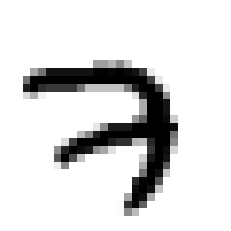

In [111]:
plt.imshow(X_train[0], cmap="binary")
plt.axis('off')
plt.show()

The labels are the class IDs (represented as uint8), from 0 to 9. Conveniently, the class IDs correspond to the digits represented in the images, so we don't need a `class_names` array:

In [112]:
y_train

array([7, 3, 4, ..., 5, 6, 8], dtype=uint8)

The validation set contains 5,000 images, and the test set contains 10,000 images:

In [113]:
X_valid.shape

(5000, 28, 28)

In [114]:
X_test.shape

(10000, 28, 28)

Let's take a look at a sample of the images in the dataset:

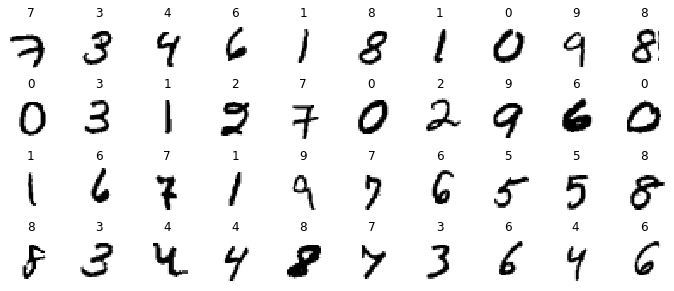

In [115]:
n_rows = 4
n_cols = 10
plt.figure(figsize=(n_cols * 1.2, n_rows * 1.2))
for row in range(n_rows):
    for col in range(n_cols):
        index = n_cols * row + col
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(X_train[index], cmap="binary", interpolation="nearest")
        plt.axis('off')
        plt.title(y_train[index], fontsize=12)
plt.subplots_adjust(wspace=0.2, hspace=0.5)
plt.show()

Let's build a simple dense network and find the optimal learning rate. We will need a callback to grow the learning rate at each iteration. It will also record the learning rate and the loss at each iteration:

In [116]:
K = keras.backend

class ExponentialLearningRate(keras.callbacks.Callback):
    def __init__(self, factor):
        self.factor = factor
        self.rates = []
        self.losses = []
    def on_batch_end(self, batch, logs):
        self.rates.append(K.get_value(self.model.optimizer.learning_rate))
        self.losses.append(logs["loss"])
        K.set_value(self.model.optimizer.learning_rate, self.model.optimizer.learning_rate * self.factor)

In [117]:
keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

In [118]:
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="relu"),
    keras.layers.Dense(100, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

We will start with a small learning rate of 1e-3, and grow it by 0.5% at each iteration:

In [119]:
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=keras.optimizers.SGD(learning_rate=1e-3),
              metrics=["accuracy"])
expon_lr = ExponentialLearningRate(factor=1.005)

Now let's train the model for just 1 epoch:

In [120]:
history = model.fit(X_train, y_train, epochs=1,
                    validation_data=(X_valid, y_valid),
                    callbacks=[expon_lr])

1719/1719 [==============================] - 2s 1ms/step - loss: 4.6604 - accuracy: 0.4887 - val_loss: 2.3911 - val_accuracy: 0.1126


We can now plot the loss as a function of the learning rate:

Text(0, 0.5, 'Loss')

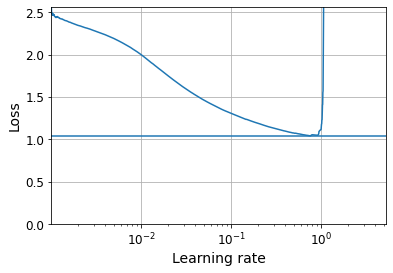

In [121]:
plt.plot(expon_lr.rates, expon_lr.losses)
plt.gca().set_xscale('log')
plt.hlines(min(expon_lr.losses), min(expon_lr.rates), max(expon_lr.rates))
plt.axis([min(expon_lr.rates), max(expon_lr.rates), 0, expon_lr.losses[0]])
plt.grid()
plt.xlabel("Learning rate")
plt.ylabel("Loss")

The loss starts shooting back up violently when the learning rate goes over 6e-1, so let's try using half of that, at 3e-1:

In [122]:
keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

In [123]:
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="relu"),
    keras.layers.Dense(100, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

In [124]:
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=keras.optimizers.SGD(learning_rate=3e-1),
              metrics=["accuracy"])

In [125]:
run_index = 1 # increment this at every run
run_logdir = os.path.join(os.curdir, "my_mnist_logs", "run_{:03d}".format(run_index))
run_logdir

'./my_mnist_logs/run_001'

In [126]:
early_stopping_cb = keras.callbacks.EarlyStopping(patience=20)
checkpoint_cb = keras.callbacks.ModelCheckpoint("my_mnist_model.h5", save_best_only=True)
tensorboard_cb = keras.callbacks.TensorBoard(run_logdir)

history = model.fit(X_train, y_train, epochs=100,
                    validation_data=(X_valid, y_valid),
                    callbacks=[checkpoint_cb, early_stopping_cb, tensorboard_cb])

Epoch 1/100
1719/1719 [==============================] - 3s 2ms/step - loss: 0.4195 - accuracy: 0.8677 - val_loss: 0.0995 - val_accuracy: 0.9724
Epoch 2/100
1719/1719 [==============================] - 2s 882us/step - loss: 0.0941 - accuracy: 0.9698 - val_loss: 0.0913 - val_accuracy: 0.9746
Epoch 3/100
1719/1719 [==============================] - 1s 845us/step - loss: 0.0650 - accuracy: 0.9792 - val_loss: 0.0785 - val_accuracy: 0.9772
Epoch 4/100
1719/1719 [==============================] - 2s 932us/step - loss: 0.0438 - accuracy: 0.9855 - val_loss: 0.0793 - val_accuracy: 0.9784
Epoch 5/100
1719/1719 [==============================] - 1s 832us/step - loss: 0.0348 - accuracy: 0.9888 - val_loss: 0.0724 - val_accuracy: 0.9812
Epoch 6/100
1719/1719 [==============================] - 1s 835us/step - loss: 0.0289 - accuracy: 0.9905 - val_loss: 0.0814 - val_accuracy: 0.9792
Epoch 7/100
1719/1719 [==============================] - 1s 868us/step - loss: 0.0230 - accuracy: 0.9926 - val_loss: 0.0

In [127]:
model = keras.models.load_model("my_mnist_model.h5") # rollback to best model
model.evaluate(X_test, y_test)

313/313 [==============================] - 0s 701us/step - loss: 0.0804 - accuracy: 0.9806


[0.08043695986270905, 0.9805999994277954]

We got over 98% accuracy. Finally, let's look at the learning curves using TensorBoard:

In [128]:
%tensorboard --logdir=./my_mnist_logs --port=6006